In [1]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", message="Spin magnitude of Bh. outside training range.")
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
filepath = "/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q:0.50_χ1:0.20_χ2:0.20_θ1:45_θ2:45_ΔΦ:90.csv"

In [3]:
# function to compute the entropy evolution using 2.5PN order:
#    - Point-Mass: 2PN 
#    - Spin-Orbit (SO): Leading Order (1.5PN) and Next-to-Leading Order (2.5PN)
#    - Spin-Spin (SS): Leading Order (2PN)

In [4]:
# initial conditions

with open(filepath, 'r') as file:
    header = [file.readline() for _ in range(3)]
    init_line = header[1]

q = float(re.search(r'q=([0-9.]+)', init_line).group(1))
chi1_mag = float(re.search(r'χ1=([0-9.]+)', init_line).group(1))
chi2_mag = float(re.search(r'χ2=([0-9.]+)', init_line).group(1))

m1 = 1.0 / (1.0 + q)
m2 = q / (1.0 + q)
eta = m1 * m2

print(f"Mass Ratio (q): {q}")
print(f"Individual Masses: m1={m1:.4f}, m2={m2:.4f}")
print(f"Symmetric Mass Ratio (eta): {eta:.4f}")
print(f"Spin Magnitudes: χ1={chi1_mag}, χ2={chi2_mag}")

Mass Ratio (q): 0.5
Individual Masses: m1=0.6667, m2=0.3333
Symmetric Mass Ratio (eta): 0.2222
Spin Magnitudes: χ1=0.2, χ2=0.2


In [5]:
# data loading

df = pd.read_csv(filepath, comment='#')
r = df['separation_M'].values
L_mag = df['angular_momentum_L'].values
theta1 = df['theta1_rad'].values
theta2 = df['theta2_rad'].values
deltaphi = df['deltaphi_rad'].values

S1_vec = np.zeros((len(r), 3))
S1_vec[:, 0] = (m1**2) * chi1_mag * np.sin(theta1)
S1_vec[:, 2] = (m1**2) * chi1_mag * np.cos(theta1)

S2_vec = np.zeros((len(r), 3))
S2_vec[:, 0] = (m2**2) * chi2_mag * np.sin(theta2) * np.cos(deltaphi)
S2_vec[:, 1] = (m2**2) * chi2_mag * np.sin(theta2) * np.sin(deltaphi)
S2_vec[:, 2] = (m2**2) * chi2_mag * np.cos(theta2)

L_vec = np.zeros((len(r), 3))
L_vec[:, 2] = L_mag

print(f"Number of simulation steps: {len(df)}")
print(f"Initial orbital separation: {r[0]:.2f} M")
print(f"Final orbital separation: {r[-1]:.2f} M")

Number of simulation steps: 10000
Initial orbital separation: 100.00 M
Final orbital separation: 10.00 M


In [6]:
# PN contributions

S1_L = S1_vec[:, 2] 
S2_L = S2_vec[:, 2]
S1_S2 = np.einsum('ij,ij->i', S1_vec, S2_vec)

# point-mass 
E_pm = - (eta / (2.0 * r)) * (
    1.0 + (9.0/4.0 + eta/12.0) / r + 
    (653.0/80.0 - 21.0/20.0 * eta + eta**2/24.0) / r**2
)

# spin-orbit (1.5PN LO and 2.5PN NLO)
E_so_lo = (1.0 / r**2.5) * ((2.0 + 1.5 * m2/m1) * S1_L + (2.0 + 1.5 * m1/m2) * S2_L)
E_so_nlo = (1.0 / r**3.5) * ((31.0/8.0 * m2/m1 + 13.0/4.0) * S1_L + (31.0/8.0 * m1/m2 + 13.0/4.0) * S2_L)

# spin-spin
E_ss = (1.0 / (2.0 * r**3)) * (3.0 * S1_L * S2_L - S1_S2)


E_bind = E_pm + E_so_lo + E_so_nlo + E_ss
M_inst = 1.0 + E_bind

print(f"Initial Binding Energy: {E_bind[0]:.6f}")
print(f"Initial Mass: {M_inst[0]:.6f}")
print(f"  > Point-Mass: {E_pm[0]:.6f}")
print(f"  > Spin-Orbit: {(E_so_lo[0] + E_so_nlo[0]):.6e}")
print(f"  > Spin-Spin: {E_ss[0]:.6e}")

Initial Binding Energy: -0.001135
Initial Mass: 0.998865
  > Point-Mass: -0.001137
  > Spin-Orbit: 2.564048e-06
  > Spin-Spin: 9.876543e-10


In [7]:
# Kerr state mapping

J_vec = L_vec + S1_vec + S2_vec
J_mag = np.linalg.norm(J_vec, axis=1)

a_inst = J_mag / (M_inst**2)

S_norm = np.full_like(a_inst, np.nan)
valid_mask = a_inst <= 1.0

root = np.sqrt(1.0 - a_inst[valid_mask]**2)
S_Kerr = 2.0 * np.pi * (M_inst[valid_mask]**2) * (1.0 + root)
S_norm[valid_mask] = S_Kerr / (4.0 * np.pi)

res = {
    'time': df['time_M'].values,
    'r': r,
    'J_norm': J_mag,
    'a_inst': a_inst,
    'S_norm': S_norm,
    'M_inst': M_inst,
    'valid_mask': valid_mask
}

print(f"Valid Kerr states identified: {np.sum(valid_mask)} out of {len(r)} points")


peak_idx = np.nanargmax(S_norm)
    
peak_S = S_norm[peak_idx]
peak_a = a_inst[peak_idx]
peak_r = r[peak_idx]
peak_t = res['time'][peak_idx]
    
print(f"Peak Predicted Entropy : {peak_S:.6f}")
print(f"Spin at Entropy Peak:     {peak_a:.6f}")
print(f"Separation at Peak :   {peak_r:.4f} M")
print(f"Time of Peak:         {peak_t:.2f} M")


Valid Kerr states identified: 2189 out of 10000 points
Peak Predicted Entropy : 0.774803
Spin at Entropy Peak:     0.805566
Separation at Peak :   10.0000 M
Time of Peak:         8963367.29 M


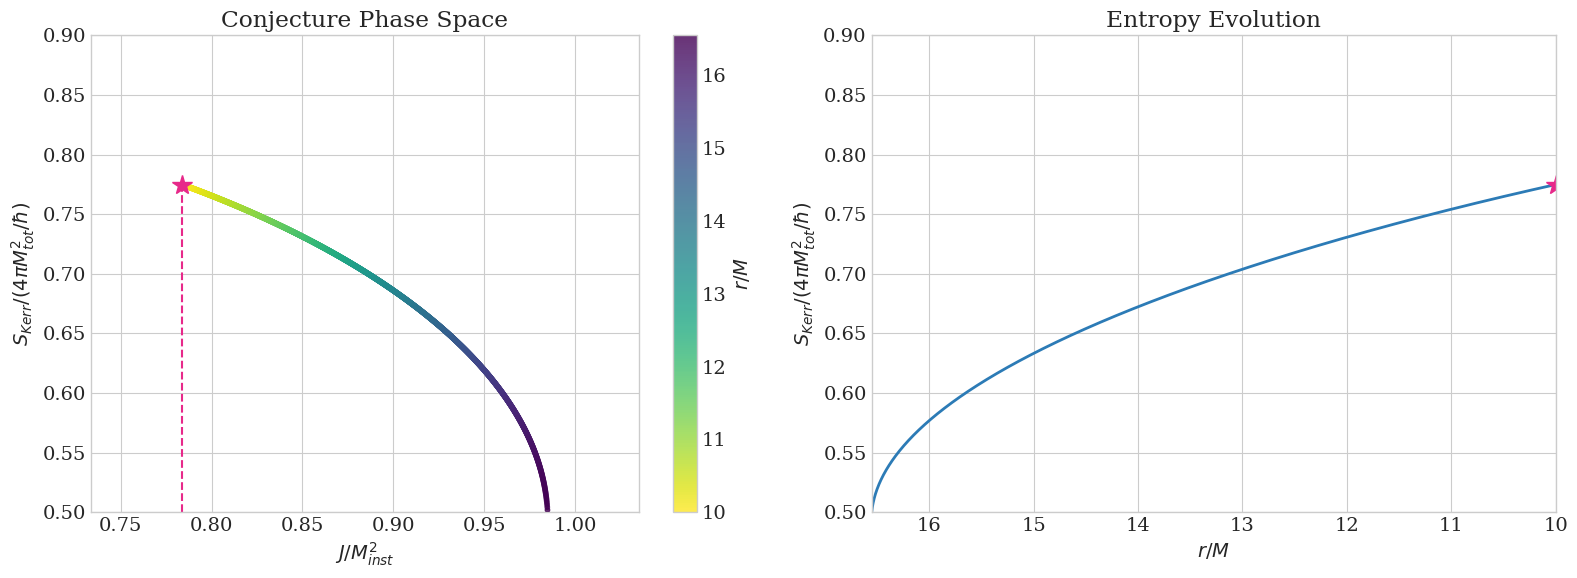

In [8]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})

J_norm = res['J_norm']
S_norm = res['S_norm']
r = res['r']
valid = res['valid_mask']
a_inst = res['a_inst']
    
J_valid = J_norm[valid]
S_valid = S_norm[valid]
r_valid = r[valid]
    
max_idx = np.nanargmax(S_valid)
J_max = J_valid[max_idx]
S_max = S_valid[max_idx]
r_max = r_valid[max_idx]
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
# Graph 1
sc1 = ax1.scatter(J_valid, S_valid, c=r_valid, cmap='viridis_r', s=10, alpha=0.8)
ax1.plot(J_max, S_max, '*', markersize=15, color='#e7298a')
ax1.vlines(J_max, ymin=0.5, ymax=S_max, color='#e7298a', linestyle='--')
ax1.set_xlabel(r'$J/M_{inst}^2$')
ax1.set_ylabel(r'$S_{Kerr} / (4\pi M_{tot}^2 / \hbar)$')
ax1.set_ylim(0.50, max(0.9, S_max + 0.05))
ax1.set_xlim(min(J_valid) - 0.05, max(J_valid) + 0.05)
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label(r'$r/M$')
ax1.set_title('Conjecture Phase Space')

# Graph 2
ax2.plot(r_valid, S_valid, color='#2c7bb6', lw=2)
ax2.plot(r_max, S_max, '*', markersize=15, color='#e7298a')
ax2.set_xlabel(r'$r/M$')
ax2.set_ylabel(r'$S_{Kerr} / (4\pi M_{tot}^2 / \hbar)$')
ax2.set_xlim(max(r_valid), min(r_valid))
ax2.set_ylim(0.50, max(0.9, S_max + 0.05))
ax2.set_title('Entropy Evolution')
    
plt.tight_layout()
plt.show()